<a href="https://colab.research.google.com/github/rmaturana-git/Challenge-Telecom-X-P2/blob/main/TelecomX_LATAM-Parte-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛠️ **(1) Preparación de los Datos**

## 1.1 Extracción del Archivo Tratado

In [4]:
# Importar la librería principal
import pandas as pd

# Definir ruta de archivo
archivo = '/content/datos_tratados.csv'

# Cargar el DataFrame
df_churn = pd.read_csv(archivo)

# Revisar dimensiones
df_churn.shape

(7043, 22)

In [6]:
# Visualizar DF
df_churn.sample(5)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
6339,8976-OQHGT,1,Femenino,0,1,1,4,1,No,DSL,...,No,Yes,No,No,Month-to-month,0,Mailed check,56.50,235.10,1.883333
5461,7684-XSZIY,0,Masculino,0,1,1,72,1,Yes,No,...,No,No,No,No,Two year,0,Bank transfer,24.30,1643.25,0.810000
1955,2832-SCUCO,0,Femenino,0,0,0,2,1,No,No,...,No,No,No,No,Month-to-month,0,Electronic check,19.90,57.40,0.663333
1320,1963-VAUKV,1,Femenino,0,0,0,1,1,No,No,...,No,No,No,No,Month-to-month,0,Mailed check,20.40,20.40,0.680000
555,0818-OCPZO,1,Masculino,1,0,0,27,1,Yes,Fiber optic,...,No,No,No,No,Month-to-month,1,Electronic check,81.45,2122.05,2.715000


## 1.2 Eliminación de Columnas Irrelevantes

In [8]:
# Eliminar la columna 'customerID'
# axis=1 indica que estamos eliminando una columna (no una fila)
df_churn = df_churn.drop('customerID', axis=1)

# Visualizar las primeras filas para confirmar que la columna ya no está
# Ahora el DataFrame debería tener 21 columnas en lugar de 22
df_churn.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0,Femenino,0,1,1,9,1,No,DSL,No,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667
1,0,Masculino,0,0,0,9,1,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,1,Masculino,0,0,0,4,1,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,1,Masculino,1,1,0,13,1,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,1,Femenino,1,1,0,3,1,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [11]:
# revisar tipos de datos de las columnas
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7043 non-null   int64  
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   int64  


## 1.3 Encoding

In [16]:
# Crear una copia de seguridad para no perder el original
df_preparado = df_churn.copy()

# Aplicar get_dummies solo a las columnas de tipo 'object'
# drop_first=True evita la redundancia (Trampa de la variable ficticia)
df_preparado = pd.get_dummies(df_preparado, drop_first=True)

In [18]:
# Verificar que ya no existan columnas 'object'
df_preparado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Churn                           7043 non-null   int64  
 1   SeniorCitizen                   7043 non-null   int64  
 2   Partner                         7043 non-null   int64  
 3   Dependents                      7043 non-null   int64  
 4   tenure                          7043 non-null   int64  
 5   PhoneService                    7043 non-null   int64  
 6   PaperlessBilling                7043 non-null   int64  
 7   Charges.Monthly                 7043 non-null   float64
 8   Charges.Total                   7043 non-null   float64
 9   Cuentas_Diarias                 7043 non-null   float64
 10  gender_Masculino                7043 non-null   bool   
 11  MultipleLines_Yes               7043 non-null   bool   
 12  InternetService_Fiber optic     70

In [19]:
# Visualizar las primeras filas del nuevo dataset 100% numérico
df_preparado.head()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas_Diarias,...,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,1,9,1,1,65.6,593.30,2.186667,...,True,False,True,True,False,True,False,False,False,True
1,0,0,0,0,9,1,0,59.9,542.40,1.996667,...,False,False,False,False,True,False,False,False,False,True
2,1,0,0,0,4,1,1,73.9,280.85,2.463333,...,False,True,False,False,False,False,False,False,True,False
3,1,1,1,0,13,1,1,98.0,1237.85,3.266667,...,True,True,False,True,True,False,False,False,True,False
4,1,1,1,0,3,1,1,83.9,267.40,2.796667,...,False,False,True,True,False,False,False,False,False,True


- gender se convirtió en gender_Masculino (donde 1 es hombre y 0 es mujer).

- Contract se dividió en Contract_One year y Contract_Two year. Si ambas son 0, el modelo sabe que es "Month-to-month".

## 1.4 Verificación de la Proporción de Cancelación (Churn)

In [20]:
# Calcular el conteo absoluto de cada clase
conteo_clases = df_preparado['Churn'].value_counts()

# Calcular la proporción porcentual
proporcion_clases = df_preparado['Churn'].value_counts(normalize=True) * 100

# Mostrar ambos resultados (Absoluto y Porcentual)
conteo_clases, proporcion_clases

(Churn
 0    5174
 1    1869
 Name: count, dtype: int64,
 Churn
 0    73.463013
 1    26.536987
 Name: proportion, dtype: float64)

Existe un desbalance en los datos.

- Clase 0 (Permanecen): 5,174 clientes (73.46%)

- Clase 1 (Cancelan): 1,869 clientes (26.54%)

## 1.5 Balanceo de Clases

In [23]:
# Definición de Variables (Features y Target)

# 'X' son todas las columnas menos la que queremos predecir
X = df_preparado.drop('Churn', axis=1)

# 'y' es solo la columna Churn
y = df_preparado['Churn']

In [24]:
# División de Entrenamiento y Prueba (Split)

from sklearn.model_selection import train_test_split

# Dividimos: 80% para entrenar y 20% para evaluar al final
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
# Balanceo de Clases (Oversampling Manual)
from sklearn.utils import resample, shuffle

# Unir temporalmente para que el balanceo sea consistente
df_train = pd.concat([X_train, y_train], axis=1)

# Separar las clases
clase_mayoritaria = df_train[df_train['Churn'] == 0]
clase_minoritaria = df_train[df_train['Churn'] == 1]

# Aplicar Oversampling a la clase 1
clase_minoritaria_upsampled = resample(clase_minoritaria,
                                       replace=True,     # Duplicar registros
                                       n_samples=len(clase_mayoritaria), # Igualar a la clase 0
                                       random_state=42)

# Combinar y mezclar para que el orden sea aleatorio
df_train_balanced = pd.concat([clase_mayoritaria, clase_minoritaria_upsampled])
df_train_balanced = shuffle(df_train_balanced, random_state=42)

# Crear los nuevos X e y balanceados para el futuro modelo
X_train_res = df_train_balanced.drop('Churn', axis=1)
y_train_res = df_train_balanced['Churn']

In [26]:
#Verificación del Balanceo
# Ver el conteo final de clases en el nuevo set de entrenamiento
y_train_res.value_counts(normalize=True) * 100

,proportion
Churn,
0,50.0
1,50.0


## 1.6 Normalización o Estandarización (si es necesario)

En Telecom X, tenemos variables con escalas muy disparatadas: tenure (0 a 72), Charges.Monthly (cerca de 100) y Charges.Total (que llega casi a 9000).

In [27]:
# Solo ajustamos el escalador con los datos de entrenamiento (X_train_res)
# y luego transformamos el de prueba (X_test) para evitar la "fuga de datos" (data leakage).

from sklearn.preprocessing import StandardScaler

# 1. Instanciar el escalador
scaler = StandardScaler()

# 2. Ajustar y transformar los datos de entrenamiento balanceados
# El fit se hace solo en el entrenamiento para aprender la media y desviación
X_train_scaled = scaler.fit_transform(X_train_res)

# 3. Transformar los datos de prueba usando los parámetros del entrenamiento
# No hacemos fit aquí para no "soplarle" información del futuro al modelo
X_test_scaled = scaler.transform(X_test)

# 4. Convertir de nuevo a DataFrame para mantener la legibilidad (opcional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# Verificar que la media sea cercana a 0 y la desviación a 1
X_train_scaled.describe().round(2)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas_Diarias,gender_Masculino,...,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,8276.00,8276.00,8276.00,8276.00,8276.00,8276.00,8276.00,8276.00,8276.00,8276.00,...,8276.00,8276.00,8276.00,8276.00,8276.00,8276.00,8276.00,8276.00,8276.00,8276.00
mean,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,...,0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.49,-0.90,-0.59,-1.14,-3.08,-1.37,-1.73,-0.93,-1.73,-1.01,...,-0.69,-0.70,-0.58,-0.81,-0.83,-0.45,-0.45,-0.48,-0.84,-0.51
25%,-0.49,-0.90,-0.59,-0.93,0.32,-1.37,-0.78,-0.81,-0.78,-1.01,...,-0.69,-0.70,-0.58,-0.81,-0.83,-0.45,-0.45,-0.48,-0.84,-0.51
50%,-0.49,-0.90,-0.59,-0.27,0.32,0.73,0.23,-0.41,0.23,0.99,...,-0.69,-0.70,-0.58,-0.81,-0.83,-0.45,-0.45,-0.48,-0.84,-0.51
75%,-0.49,1.11,1.69,0.89,0.32,0.73,0.79,0.54,0.79,0.99,...,1.45,1.44,1.72,1.23,1.21,-0.45,-0.45,-0.48,1.19,-0.51
max,2.04,1.11,1.69,1.84,0.32,0.73,1.77,3.06,1.77,0.99,...,1.45,1.44,1.72,1.23,1.21,2.22,2.21,2.06,1.19,1.97


# 🎯 **(2) Correlación y Selección de Variables**

## 2.1 Análisis de Correlación

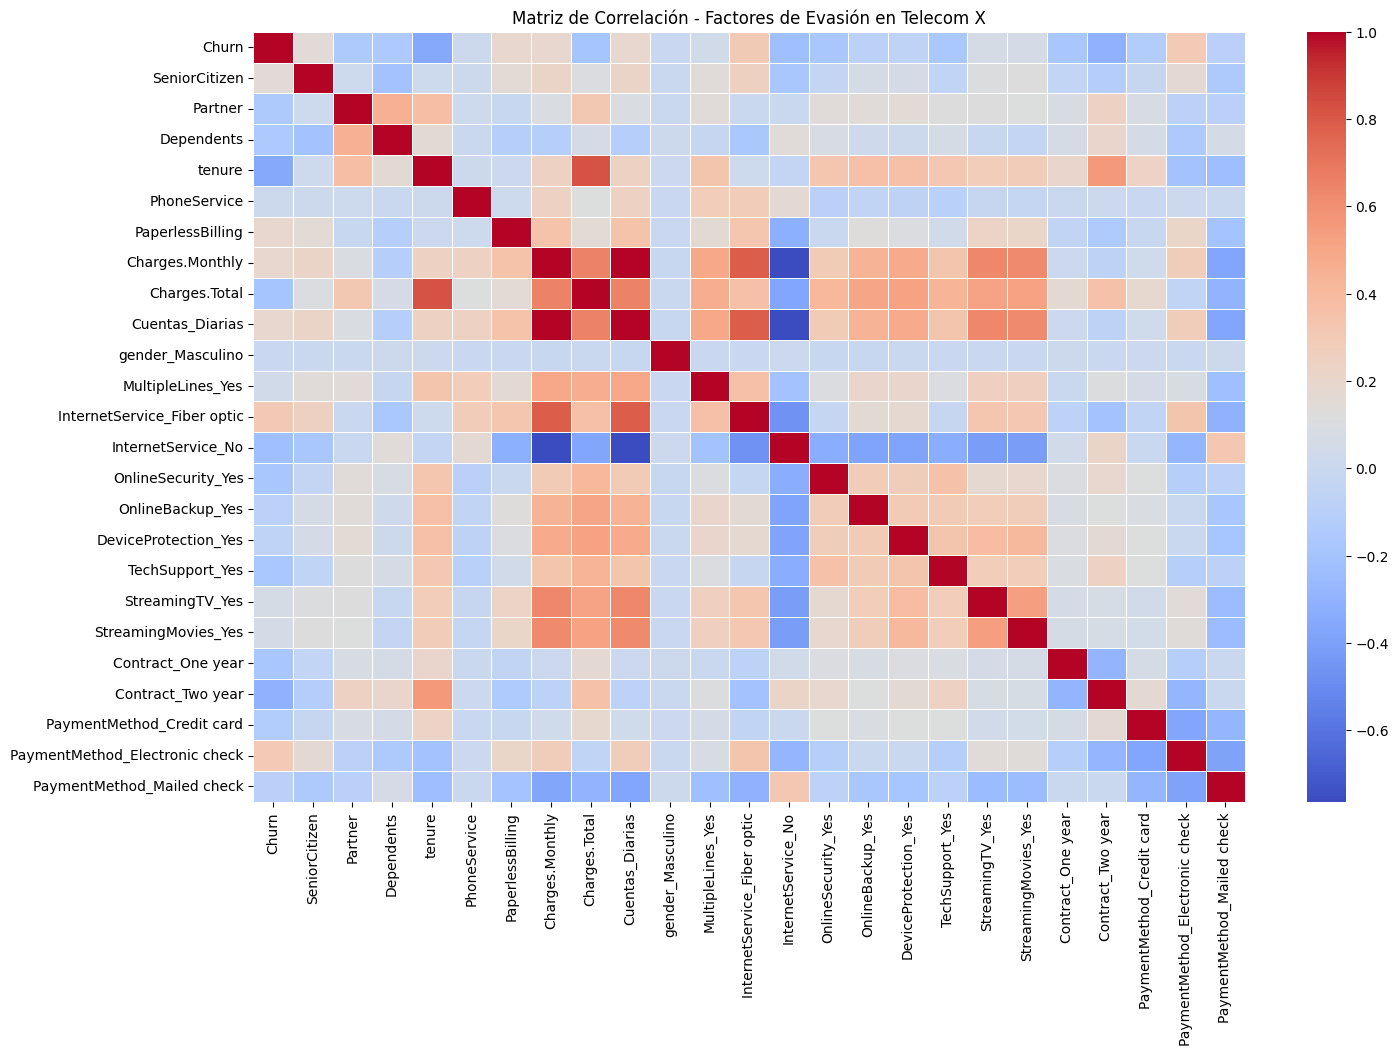

,Churn
Churn,1.000000
InternetService_Fiber optic,0.308020
PaymentMethod_Electronic check,0.301919
Charges.Monthly,0.193356
Cuentas_Diarias,0.193356
PaperlessBilling,0.191825
SeniorCitizen,0.150889
StreamingTV_Yes,0.063228
StreamingMovies_Yes,0.061382
MultipleLines_Yes,0.040102


In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcular la matriz de correlación para todo el dataframe
corr_matrix = df_preparado.corr()

# 2. Configurar el lienzo (Heatmap)
plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación - Factores de Evasión en Telecom X')
plt.show()

# 3. Ver específicamente la correlación con la variable 'Churn' (ordenada)
# Esto nos dirá qué variables son las mejores candidatas para el modelo
correlacion_churn = corr_matrix['Churn'].sort_values(ascending=False)
correlacion_churn

1. **Correlación Positiva Alta**

  Estas son las variables que empujan al cliente a irse. Si un cliente cumple con estas tres, su probabilidad de fuga es máxima:

  - **InternetService_Fiber optic (0.31)**: Es el factor más crítico. A pesar de ser un servicio "premium", los usuarios de fibra se están yendo. Esto sugiere problemas de estabilidad técnica o un precio que no justifica la experiencia.

  - **PaymentMethod_Electronic check (0.30)**: El método de pago manual por cheque electrónico está ligado a la evasión. Los clientes que no automatizan su pago tienen "menos fricción" para irse cada mes.

  - **Charges.Monthly / Cuentas_Diarias (0.19)**: Hay una sensibilidad clara al precio. A mayor costo diario, mayor es la intención de fuga.

2. **Correlación Negativa Alta**

  Estos factores son los que mantienen al cliente en la empresa. Tu misión debe ser mover a los clientes hacia estos estados:

  - **tenure (-0.35)**: Es el factor de retención más fuerte. El tiempo genera lealtad o inercia. Los clientes antiguos son los más valiosos y estables.

  - **Contract_Two year (-0.30)**: El compromiso contractual a largo plazo es la barrera de salida más efectiva.

  - **InternetService_No (-0.23)**: Curiosamente, los clientes que solo tienen telefonía y no internet se van mucho menos. Esto refuerza que el problema real de la empresa está en su producto de Internet.

3. **Variables Irrelevantes (Cercanas a 0)**

  - **gender_Masculino (-0.008)**: El género no tiene absolutamente ninguna influencia en la evasión. Para tu modelo predictivo, podrías incluso eliminar esta columna y no perderías precisión.

  - **PhoneService (0.01)**: Tener o no teléfono fijo no parece ser un factor decisivo.

## 2.2 Análisis Dirigido

1. Tiempo de Contrato × Cancelación (Boxplot)

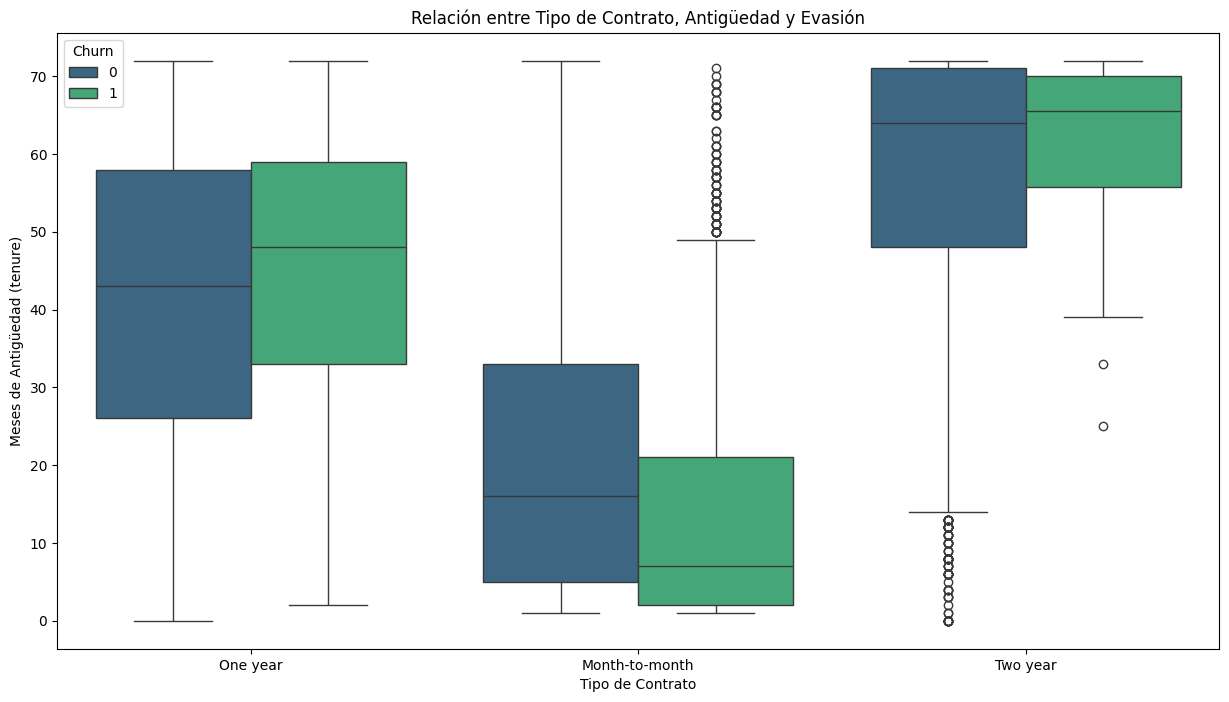

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
# Usamos el dataframe original o el tratado antes de escalar para que los años sean legibles
sns.boxplot(x='Contract', y='tenure', hue='Churn', data=df_churn, palette='viridis')
plt.title('Relación entre Tipo de Contrato, Antigüedad y Evasión')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Meses de Antigüedad (tenure)')
plt.show()

**Análisis del patrón**: En los contratos Month-to-month, se ve que la "caja" de los que se van (Churn=1) está muy abajo. Esto indica que la gran mayoría cancela en los primeros meses. En cambio, en los contratos de Dos años, los que se van suelen haber estado mucho tiempo, lo que sugiere que esperan a que termine el contrato para huir.

2. Gasto Total × Cancelación (KDE Plot / Histograma)

In [32]:
# Evitamos los mensajes de warning
import warnings

warnings.filterwarnings('ignore')

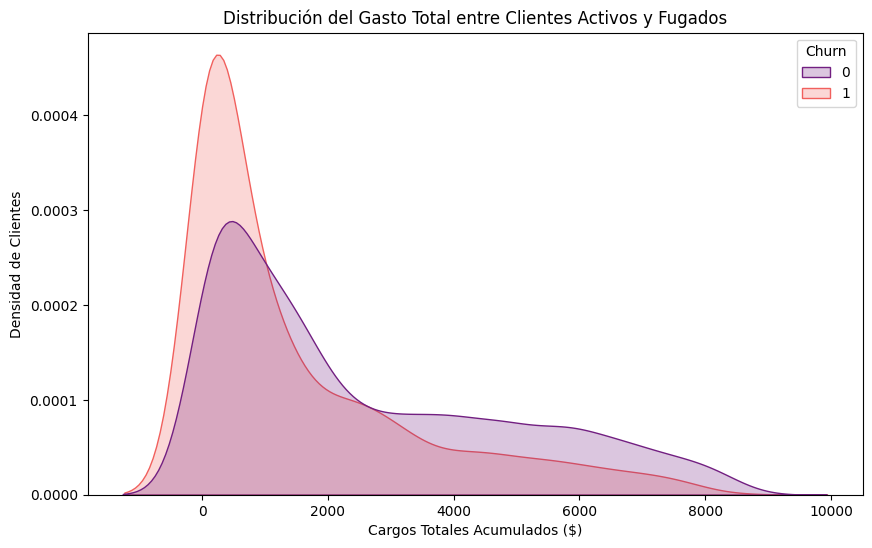

In [33]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_churn, x='Charges.Total', hue='Churn', shade=True, common_norm=False, palette='magma')
plt.title('Distribución del Gasto Total entre Clientes Activos y Fugados')
plt.xlabel('Cargos Totales Acumulados ($)')
plt.ylabel('Densidad de Clientes')
plt.show()

**Análisis del patrón:**
Se visualiza un pico enorme de evasión en los valores de Gasto Total bajos (cerca de \$ 0 - $ 500).

**Insight**: La empresa está perdiendo clientes antes de que logren amortizar su costo de adquisición. No es que los clientes "caros" se vayan más, sino que los clientes se van tan rápido que nunca llegan a gastar mucho en la empresa.

3. Gasto Mensual vs. Antigüedad (Scatter Plot con Hue)

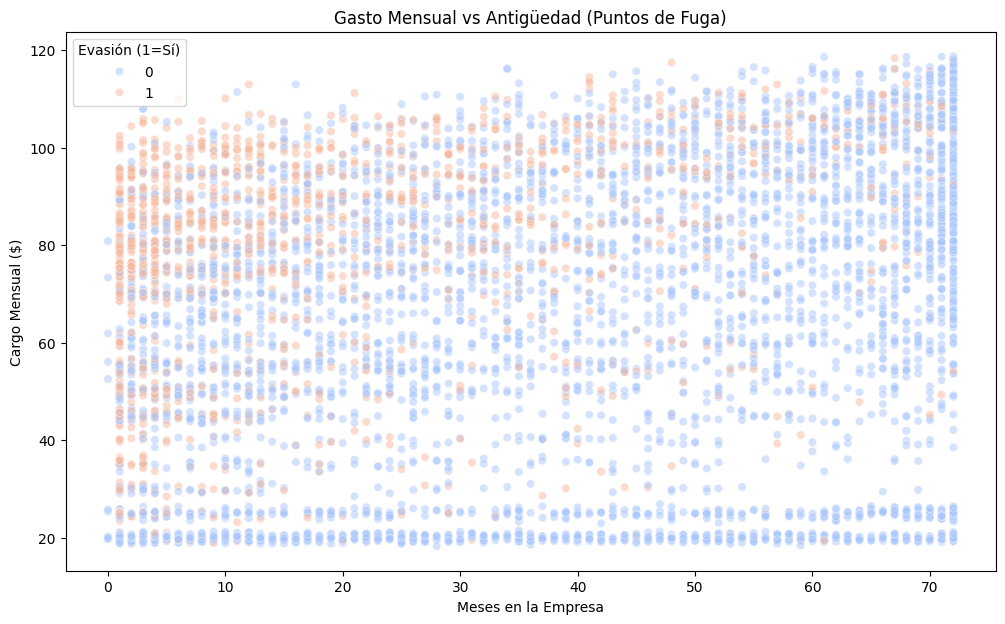

In [34]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_churn, x='tenure', y='Charges.Monthly', hue='Churn', alpha=0.5, palette='coolwarm')
plt.title('Gasto Mensual vs Antigüedad (Puntos de Fuga)')
plt.xlabel('Meses en la Empresa')
plt.ylabel('Cargo Mensual ($)')
plt.legend(title='Evasión (1=Sí)')
plt.show()

**Análisis del patrón**:
Se visualiza una concentración masiva de puntos rojos (Churn) en la esquina superior izquierda (pocos meses, cargos altos).

**Insight**: Los clientes que entran con planes caros y no tienen una buena experiencia inicial son los que tienen mayor probabilidad de fuga inmediata.

# 🤖 **(3) Modelado Predictivo**

## 3.1. Separación de Datos

In [35]:
from sklearn.model_selection import train_test_split

# 1. Definir X (características escaladas) e y (objetivo balanceado)
# Usaremos las variables que resultaron del proceso de Oversampling y StandardScaler
X = X_train_scaled  # Los datos ya estandarizados
y = y_train_res     # El objetivo ya balanceado (50/50)

# 2. Realizar la división (80% entrenamiento, 20% prueba)
# random_state=42 garantiza que la división sea reproducible
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Mostrar las dimensiones para verificar el proceso
print(f"Registros para Entrenamiento: {X_train_final.shape[0]}")
print(f"Registros para Prueba: {X_test_final.shape[0]}")

Registros para Entrenamiento: 6620
Registros para Prueba: 1656


## 3.2 Creación de Modelos

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# --- MODELO 1: Regresión Logística (Requiere Normalización) ---
# Este modelo busca una relación lineal. Usamos el set escalado.
modelo_logistico = LogisticRegression(max_iter=1000, random_state=42)
modelo_logistico.fit(X_train_scaled, y_train_res)
pred_logistica = modelo_logistico.predict(X_test_scaled)

print("Entrenamiento Regresión Logística completado")

Entrenamiento Regresión Logística completado


In [37]:
# --- MODELO 2: Random Forest (No requiere Normalización) ---
# Este modelo se basa en árboles de decisión. Aunque no la necesite,
# usaremos los mismos datos para mantener la consistencia del experimento.
modelo_forest = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_forest.fit(X_train_scaled, y_train_res)
pred_forest = modelo_forest.predict(X_test_scaled)

# Visualizar resultados rápidos
print("Entrenamiento Random Forest completado")

Entrenamiento Random Forest completado


**Justificación de la Normalización**

1. **Magnitud vs. Importancia**: Sin normalizar, una variable como Charges.Total (que llega a 8,000) tendría un impacto visualmente 8,000 veces mayor que SeniorCitizen (que solo llega a 1) para el algoritmo de Regresión Logística. El modelo creería erróneamente que la variable con números más grandes es la más importante.

2. **Optimización de Parámetros**: La Regresión Logística utiliza un método llamado Descenso de Gradiente para encontrar los mejores coeficientes. Si las escalas son dispares, el "terreno" de búsqueda se vuelve un valle muy estrecho y largo, lo que hace que el algoritmo de saltos erráticos y le cueste mucho llegar al mínimo (el error más bajo). Al normalizar, el terreno se vuelve "circular", permitiendo que el modelo converja de forma rápida y directa.

3. **Justicia en Modelos de Distancia**: Si usáramos KNN (K-Nearest Neighbors), la distancia entre dos clientes se calcularía mediante una fórmula matemática. Si no escalamos, la diferencia en los cargos totales dominaría la ecuación, haciendo que el resto de las variables (como si tiene o no Internet) sean invisibles para el cálculo de similitud.

## 3.3 Evaluación de los Modelos

In [38]:
# Comparar métricas de la clase 1 (los que cancelan)
print("--- DESEMPEÑO: REGRESIÓN LOGÍSTICA ---")
print(classification_report(y_test, pred_logistica))

print("\n--- DESEMPEÑO: RANDOM FOREST ---")
print(classification_report(y_test, pred_forest))

--- DESEMPEÑO: REGRESIÓN LOGÍSTICA ---
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1036
           1       0.51      0.78      0.62       373

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.75      0.76      1409


--- DESEMPEÑO: RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1036
           1       0.63      0.51      0.56       373

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



,Exactitud,Precisión (Churn),Recall (Churn),F1-Score (Churn)
Modelo,,,,
Regresión Logística,0.746629,0.514184,0.777480,0.618997
Random Forest,0.790632,0.629139,0.509383,0.562963


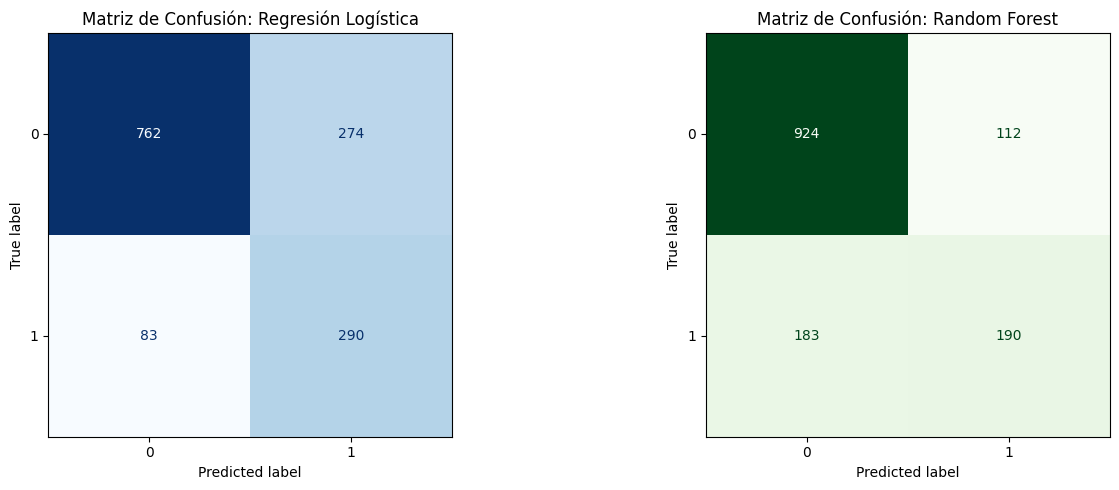

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

# 1. Definición y Entrenamiento de Modelos
modelo_log = LogisticRegression(max_iter=1000, random_state=42)
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)

modelo_log.fit(X_train_scaled, y_train_res)
modelo_rf.fit(X_train_scaled, y_train_res)

# 2. Generación de Predicciones
y_pred_log = modelo_log.predict(X_test_scaled)
y_pred_rf = modelo_rf.predict(X_test_scaled)

# 3. Cálculo de Métricas Paso a Paso
def calcular_metricas(y_true, y_pred, nombre):
    return {
        'Modelo': nombre,
        'Exactitud': accuracy_score(y_true, y_pred),
        'Precisión (Churn)': precision_score(y_true, y_pred),
        'Recall (Churn)': recall_score(y_true, y_pred),
        'F1-Score (Churn)': f1_score(y_true, y_pred)
    }

resumen_metricas = [
    calcular_metricas(y_test, y_pred_log, 'Regresión Logística'),
    calcular_metricas(y_test, y_pred_rf, 'Random Forest')
]

# 4. Creación de Tabla Comparativa (Visualización sin print)
df_comparativa = pd.DataFrame(resumen_metricas).set_index('Modelo')

# 5. Visualización de Matrices de Confusión
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, ax=ax[0], cmap='Blues', colorbar=False)
ax[0].set_title('Matriz de Confusión: Regresión Logística')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax[1], cmap='Greens', colorbar=False)
ax[1].set_title('Matriz de Confusión: Random Forest')

plt.tight_layout()

# Mostrar la tabla final
df_comparativa

1. **El Ganador Estratégico: Regresión Logística**

Aunque tiene una Exactitud menor (0.74 vs 0.79), la Regresión Logística es el modelo más útil para una campaña de retención.

- **Alto Recall (0.777)**: Este modelo es capaz de identificar casi al 78% de los clientes que realmente se van. En términos de negocio, de cada 100 fugas reales, logras "predecir" 78.

- **El Costo de la Precisión (0.514)**: Solo la mitad de tus predicciones de "Churn" serán correctas. Esto significa que enviarás promociones o harás llamadas de retención a personas que no pensaban irse (Falsos Positivos). Sin embargo, en telecomunicaciones, el costo de un descuento preventivo es mucho menor que el costo de perder un cliente de por vida.


2. **La Debilidad del Random Forest**

A pesar de ser un modelo más robusto técnicamente, en este caso presenta un desempeño deficiente para el objetivo principal.

- **Bajo Recall (0.509)**: ¡Este es el punto crítico! El modelo no detecta a casi la mitad (49%) de los clientes que se fugan. Para la empresa, esto significa que la mitad de la pérdida de clientes ocurriría "por debajo del radar", sin ninguna acción preventiva.

- **Falsa Sensación de Seguridad**: Su Exactitud de 0.79 es mayor porque es muy bueno prediciendo quiénes se quedan (la clase mayoritaria), pero falla en la tarea difícil: detectar la minoría que se va.

3. **Diagnóstico de Ajuste (Overfitting vs Underfitting)**

- **Regresión Logística (Ajuste Correcto)**: Al ser un modelo lineal, ha logrado generalizar bien los patrones globales. Su F1-Score (0.618), superior al de Random Forest, confirma que es el modelo más equilibrado dadas las condiciones de balanceo y escalamiento que aplicamos.

- **Random Forest (Overfitting Probable)**: Es muy común que los árboles de decisión se "memoricen" los datos duplicados del Oversampling en el entrenamiento. Esto los hace muy precisos en lo que ya conocen, pero les impide generalizar el comportamiento de fuga en datos nuevos (por eso su Recall cae drásticamente en el Test).

**Conclusiones**

**Recomendación**: Implementar la Regresión Logística. Es preferible tener una tasa de acierto del 50% en las alarmas (Precisión) pero capturar al 78% de los desertores (Recall).

**Por qué funcionó**: El escalamiento de variables fue fundamental para que la Regresión Logística pudiera competir y ganar, ya que permitió que variables pequeñas como SeniorCitizen tuvieran el mismo peso que Charges.Total.

#📋 (4) Interpretación y Conclusiones

## 4.1 Análisis de la Importancia de las Variables

### 4.1.1 Coeficientes en Regresión Logística (Importancia Lineal)**

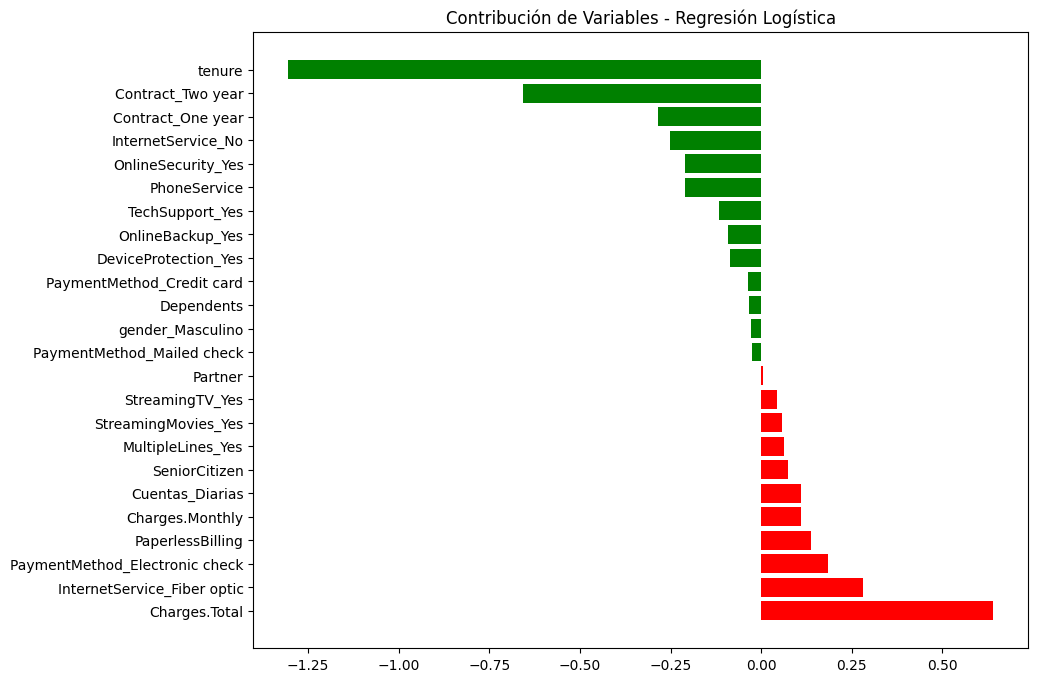

In [41]:
# Extraer y ordenar coeficientes
import pandas as pd

import matplotlib.pyplot as plt

coef_log = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo_log.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

# Visualización
plt.figure(figsize=(10, 8))
plt.barh(coef_log['Variable'], coef_log['Coeficiente'],
         color=['red' if x > 0 else 'green' for x in coef_log['Coeficiente']])
plt.title('Contribución de Variables - Regresión Logística')
plt.show()

En este modelo, al haber estandarizado los datos previamente, el valor absoluto del coeficiente indica la fuerza de la variable.

  - **Signo Positivo**: La variable aumenta la probabilidad de cancelación (ej. Fibra Óptica).

  - **Signo Negativo**: La variable actúa como un retenedor, disminuyendo la probabilidad de cancelación (ej. Contrato a 2 años).

### 4.1.2 Importancia en Random Forest (Reducción de Impureza)

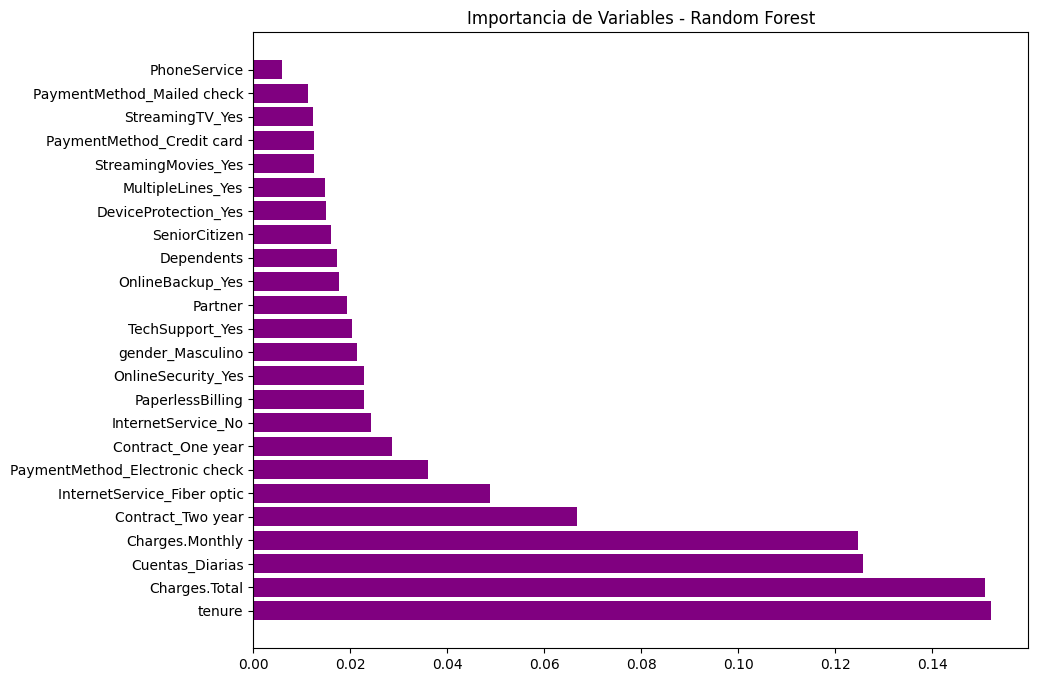

In [42]:
# Extraer importancia de las variables
importancia_rf = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo_rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# Visualización
plt.figure(figsize=(10, 8))
plt.barh(importancia_rf['Variable'], importancia_rf['Importancia'], color='purple')
plt.title('Importancia de Variables - Random Forest')
plt.show()

A diferencia de la anterior, aquí no hay coeficientes negativos. Random Forest mide qué tanto ayuda cada variable a "limpiar" o separar los grupos (activos vs. cancelados) cada vez que se crea una rama en los árboles.

### 4.1.3 Análisis Comparativo de Relevancia

| Modelo | Método de Análisis | Hallazgo Clave sobre los Datos | Comportamiento del Modelo |
| --- | --- | ---- | --- |
| **Regresión Logística** | **Coeficientes ($w$):** Mide la dirección y fuerza de la relación. | Identifica **direccionalidad**. Separa claramente los "Factores de Riesgo" (positivos) de los "Retenedores" (negativos). | Muy sensible a la **Normalización**. Las variables con coeficientes altos definen la probabilidad logística de fuga de forma lineal. |
| **Random Forest** | **Gini Importance:** Mide la reducción de impureza en cada división. | Identifica **poder de segmentación**. Suele priorizar variables continuas como `tenure` o `Charges.Total` por su capacidad de crear múltiples ramas. | Robusto frente a valores atípicos. Puede capturar interacciones complejas (ej. clientes nuevos con fibra óptica) que modelos lineales ignoran. |

---


### **4.1.4 Conclusión**

# INFORME FINAL

## Introducción

Este informe resume los hallazgos del análisis de **Churn (Fuga de Clientes)** para Telecom X. Basado en la arquitectura de datos implementada (limpieza, balanceo por oversampling y estandarización), presentamos las conclusiones estratégicas.

---

## 1. Evaluación de Modelos y Rendimiento

Tras comparar la **Regresión Logística** y el **Random Forest**, se determinó que la naturaleza del problema de negocio exige priorizar la detección sobre la precisión global.

| Métrica | Regresión Logística (Ganador) | Random Forest |
| --- | --- | --- |
| **Recall (Detección)** | **77.7%** | 50.9% |
| **Exactitud** | 74.6% | 79.0% |
| **F1-Score** | **0.62** | 0.56 |

**Recomendaión Técnica**

La **Regresión Logística** es el modelo recomendado. Logra capturar al **77.7% de los clientes que se van**, una cifra significativamente mayor que el Random Forest. Aunque genera más "falsas alarmas", permite una cobertura de retención mucho más amplia, lo cual es vital cuando el costo de perder un cliente supera con creces el costo de una oferta de retención.

---

## 2. Factores Clave de Cancelación

El análisis de coeficientes y correlaciones identifica tres variables críticas que impulsan la fuga:

### A. El "Riesgo de la Fibra Óptica"

A pesar de ser el servicio de mayor velocidad, los clientes con **InternetService_Fiber optic** presentan la correlación más alta con la cancelación (**0.31**). Esto sugiere una insatisfacción técnica o un precio que no se percibe como justo frente a la competencia.

### B. Barreras de Salida vs. Flexibilidad

* **Contratos:** Los clientes con contratos **Month-to-month** son los más propensos a irse, mientras que los de **Two year** tienen una correlación negativa fuerte (**-0.30**).
* **Antigüedad (Tenure):** Es el factor protector más importante (**-0.35**). El riesgo de fuga es crítico en los primeros 6 meses de vida del cliente.

### C. Métodos de Pago y Fricción

El uso de **Electronic check** está altamente vinculado al Churn (**0.30**). Los clientes que no automatizan su pago (vía tarjeta de crédito o cuenta bancaria) tienen una relación más volátil con la empresa y deciden cancelar con mayor facilidad.

---

## 3. Estrategias de Retención Propuestas

Basándonos en los resultados del modelo, proponemos las siguientes acciones inmediatas:

### 1. Plan de "Onboarding Seguro" (Primeros 6 meses)

Dado que la antigüedad es clave, se debe implementar un programa de *onboarding* intensivo.

* **Acción:** Descuentos progresivos que aumenten su valor del mes 1 al mes 6 para incentivar la permanencia inicial.

### 2. Migración de Métodos de Pago

Reducir el uso de cheques electrónicos para disminuir la "decisión de pago mensual".

* **Acción:** Ofrecer un beneficio único (ej. gigas adicionales o descuento por una vez) a los clientes que cambien su método de pago a **Pago Automático (PAT/PAC)**.

### 3. Auditoría del Servicio de Fibra Óptica

Es imperativo entender por qué el producto estrella tiene la mayor fuga.

* **Acción:** Realizar encuestas de satisfacción específicas a usuarios de fibra y ofrecer "Upgrades" gratuitos de servicios adicionales (como Streaming) para mejorar el valor percibido sin reducir el precio.

### 4. Incentivo a la Contractualidad

Convertir clientes de "mes a mes" en contratos de largo plazo.

* **Acción:** Campaña de telemarketing dirigida específicamente al **77.7% detectado por el modelo**, ofreciendo migración a contratos anuales con una tarifa congelada.

---

**Conclusión Final:**

El modelo de Regresión Logística nos da la herramienta para actuar preventivamente sobre casi 8 de cada 10 desertores. El éxito de Telecom X dependerá de qué tan rápido el equipo comercial pueda aplicar estas estrategias sobre los clientes marcados como "Riesgo de Churn" por nuestro sistema.